    ECM-1_setpoint_19C -> common O&M-1
    ECM-3_setpoint_19C_reschedule_8_8_8 -> common O&M-2
    ECM-2_reschedule_8_8_8 -> common O&M-3
    ECM-5_reschedule_8_8_8_default_infiltration -> common O&M-4

    E+ O&M-1 -> common O&M-1
    E+ O&M-2 -> common O&M-2
    E+ O&M-3 -> common O&M-3
    E+ O&M-5 -> common O&M-4

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# 1. Paths
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")

eplus_ecm_path = (
    pred_dir / "ecm_savings_daily_EPlus_4P_FEBMAR_LoD1to3.csv"
)

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 2. Harmonisation maps
# ============================================================

quality_map = {
    # E+
    "beta": "LoD-1",
    "gamma": "LoD-2",
    "yearly": "LoD-3",
    "_beta": "LoD-1",
    "_gamma": "LoD-2",
    "bY": "LoD-3",

    # RC
    "default_occ": "LoD-1",
    "ONSITE_occ": "LoD-2",
    "bldg_LoD_Y": "LoD-3",
}

quality_label_map = {
    "LoD-1": r"LoD-1",
    "LoD-2": r"LoD-2",
    "LoD-3": r"LoD-3",
}

# E+ original ECM names -> common names used for RC comparison
# Based on your note:
# O&M-1 -> O&M-1 for RC
# O&M-2 -> O&M-2 for RC
# O&M-3 -> O&M-3 for RC
# O&M-5 -> O&M-4 for RC
eplus_ecm_to_common = {
    "O&M-1": "O&M-1",
    "O&M-2": "O&M-2",
    "O&M-3": "O&M-3",
    "O&M-5": "O&M-4",

    # Keep these, but they may not have direct RC equivalents.
    "O&M-4": "E+ only: O&M-4",
    "O&M-6": "E+ only: O&M-6",
}

# RC exported ECM names -> common names
rc_ecm_to_common = {
    "ECM-1_setpoint_19C": "O&M-1",
    "ECM-3_setpoint_19C_reschedule_8_8_8": "O&M-2",
    "ECM-2_reschedule_8_8_8": "O&M-3",

    # This matches your note that E+ O&M-5 corresponds to RC O&M-4.
    "ECM-4_setpoint_19C_default_infiltration": "O&M-4",

    # Keep this separately because it is not clearly one of the four common ECMs.
    "ECM-5_reschedule_8_8_8_default_infiltration": "RC only: setpoint + default infiltration",
}

ecm_label_map = {
    "O&M-1": "O&M-1:\nSetpoint",
    "O&M-2": "O&M-2:\nSetpoint\n+ schedule",
    "O&M-3": "O&M-3:\nSchedule",
    "O&M-4": "O&M-4:\nSchedule\n+ window",
    "E+ only: O&M-4": "E+ only:\nO&M-4",
    "E+ only: O&M-6": "E+ only:\nO&M-6",
    "RC only: setpoint + default infiltration": "RC only:\nSetpoint\n+ window",
}

common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]


# ============================================================
# 3. Load E+ ECM savings
# ============================================================

def load_eplus_ecm_savings(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ ECM savings file: {path}")

    df = pd.read_csv(path)

    if "scenario" not in df.columns:
        raise ValueError("E+ file needs a 'scenario' column.")

    if "ecm" not in df.columns:
        raise ValueError("E+ file needs an 'ecm' column.")

    df["source"] = "EPlus"
    df["engine"] = "EnergyPlus"
    df["model_name"] = "EnergyPlus"

    df["data_quality"] = df["scenario"].map(quality_map)

    if "scenario_group" in df.columns:
        df["data_quality"] = df["data_quality"].fillna(
            df["scenario_group"].map(quality_map)
        )

    df["ecm_common"] = df["ecm"].map(eplus_ecm_to_common).fillna(df["ecm"])
    df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

    return df


# ============================================================
# 4. Load RC ECM savings
# ============================================================

def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"
    return "RC"


def infer_rc_scenario_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"
    return "unknown"


def load_rc_ecm_savings(base_date, rc_run_ids):
    dfs = []
    missing = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "ecm_savings_daily.csv"
        )

        if not path.exists():
            missing.append(path)
            continue

        df = pd.read_csv(path)

        scenario_group = infer_rc_scenario_group(run_label)
        model_name = infer_rc_model_name(run_label)

        df["source"] = "RC"
        df["engine"] = model_name
        df["model_name"] = model_name
        df["experiment_id"] = run_label
        df["scenario"] = scenario_group
        df["scenario_group"] = scenario_group
        df["data_quality"] = quality_map.get(scenario_group, "unknown")

        if "ecm" not in df.columns:
            raise ValueError(f"RC file has no 'ecm' column: {path}")

        df["ecm_common"] = df["ecm"].map(rc_ecm_to_common).fillna(df["ecm"])
        df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

        if "saving_frac" not in df.columns and "saving_rel" in df.columns:
            df["saving_frac"] = df["saving_rel"] / 100.0

        dfs.append(df)

    if missing:
        print("[WARN] Missing RC ECM files:")
        for p in missing:
            print("   ", p)

    if not dfs:
        raise ValueError("No RC ECM savings files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 5. Combine and save
# ============================================================

ecm_eplus = load_eplus_ecm_savings(eplus_ecm_path)

ecm_rc = load_rc_ecm_savings(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
)

ecm_savings_all = pd.concat(
    [ecm_eplus, ecm_rc],
    ignore_index=True,
)

# Keep only common comparable ECMs and LoD-1 to LoD-3
ecm_savings_common = ecm_savings_all[
    ecm_savings_all["ecm_common"].isin(common_ecm_order)
    & ecm_savings_all["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
].copy()

ecm_savings_common["ecm_label"] = pd.Categorical(
    ecm_savings_common["ecm_label"],
    categories=[ecm_label_map[x] for x in common_ecm_order],
    ordered=True,
)

ecm_savings_common["data_quality"] = pd.Categorical(
    ecm_savings_common["data_quality"],
    categories=["LoD-1", "LoD-2", "LoD-3"],
    ordered=True,
)

ecm_savings_common["engine"] = pd.Categorical(
    ecm_savings_common["engine"],
    categories=["EnergyPlus", "5R1C", "3R2C"],
    ordered=True,
)

display(
    ecm_savings_common.groupby(
        ["engine", "data_quality", "ecm_common"]
    )["sample_id"].nunique()
)

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_71834/938806982.py:248: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecm_savings_common.groupby(


engine      data_quality  ecm_common
EnergyPlus  LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
5R1C        LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                 

Saved figure to: _json/_run/JUN11/_prediction_daily/ecm_savings_absolute_3engines_3LoD.png


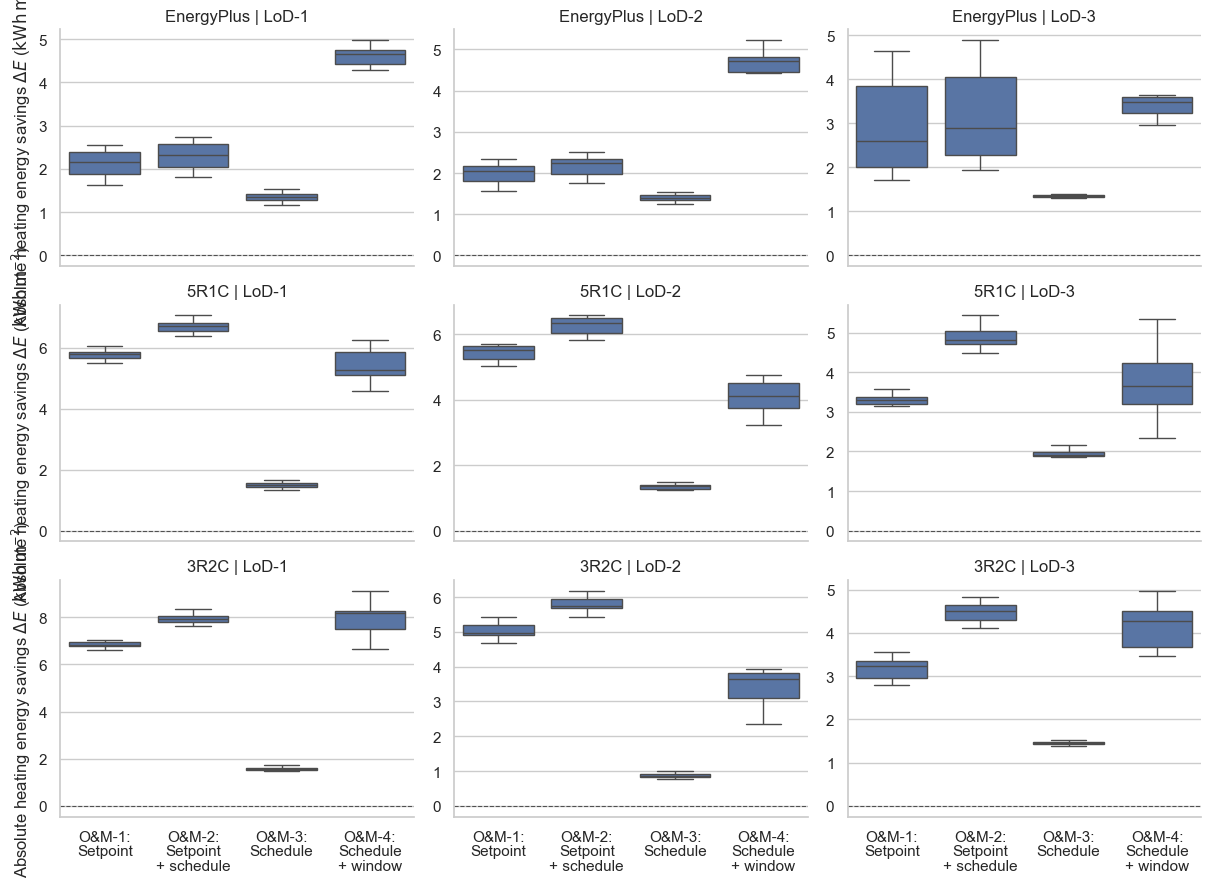

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["text.usetex"] = False

g_abs = sns.catplot(
    data=ecm_savings_common,
    x="ecm_label",
    y="saving_abs",
    row="engine",
    col="data_quality",
    kind="box",
    order=[ecm_label_map[x] for x in common_ecm_order],
    row_order=["EnergyPlus", "5R1C", "3R2C"],
    col_order=["LoD-1", "LoD-2", "LoD-3"],
    showfliers=False,
    linewidth=1,
    height=3.0,
    aspect=1.35,
    sharey=False,
)

g_abs.set_axis_labels(
    "",
    r"Absolute heating energy savings $\Delta E$ ($\mathrm{kWh\,m^{-2}}$)",
)

g_abs.set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
)

for ax in g_abs.axes.flat:
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.tick_params(axis="x", rotation=0)

    for tick in ax.get_xticklabels():
        tick.set_multialignment("center")
        tick.set_linespacing(1.05)

plt.tight_layout()

abs_path = pred_dir / "ecm_savings_absolute_3engines_3LoD.png"
g_abs.figure.savefig(abs_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {abs_path}")
plt.show()

Saved figure to: _json/_run/JUN11/_prediction_daily/ecm_savings_relative_3engines_3LoD.png


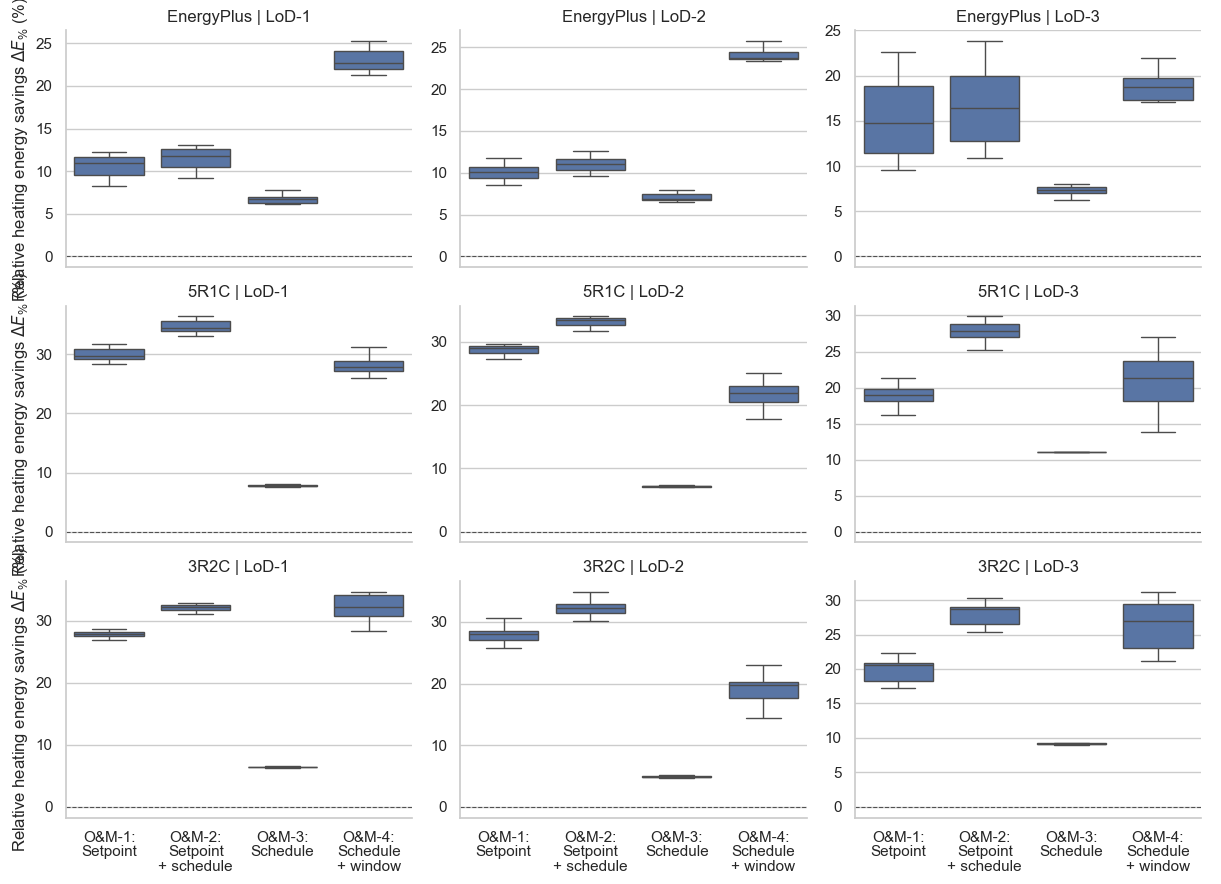

In [3]:
g_rel = sns.catplot(
    data=ecm_savings_common,
    x="ecm_label",
    y="saving_rel",
    row="engine",
    col="data_quality",
    kind="box",
    order=[ecm_label_map[x] for x in common_ecm_order],
    row_order=["EnergyPlus", "5R1C", "3R2C"],
    col_order=["LoD-1", "LoD-2", "LoD-3"],
    showfliers=False,
    linewidth=1,
    height=3.0,
    aspect=1.35,
    sharey=False,
)

g_rel.set_axis_labels(
    "",
    r"Relative heating energy savings $\Delta E_{\%}$ (%)",
)

g_rel.set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
)

for ax in g_rel.axes.flat:
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.tick_params(axis="x", rotation=0)

    for tick in ax.get_xticklabels():
        tick.set_multialignment("center")
        tick.set_linespacing(1.05)

plt.tight_layout()

rel_path = pred_dir / "ecm_savings_relative_3engines_3LoD.png"
g_rel.figure.savefig(rel_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {rel_path}")
plt.show()

# RANKING BASED PLOTS

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


# ============================================================
# 1. Correct ECM harmonisation
# ============================================================

rc_ecm_to_common = {
    "ECM-1_setpoint_19C": "O&M-1",
    "ECM-3_setpoint_19C_reschedule_8_8_8": "O&M-2",
    "ECM-2_reschedule_8_8_8": "O&M-3",
    "ECM-4_setpoint_19C_default_infiltration": "O&M-4",
    "ECM-5_reschedule_8_8_8_default_infiltration": "RC only: setpoint + default infiltration",
}

eplus_ecm_to_common = {
    "O&M-1": "O&M-1",
    "O&M-2": "O&M-2",
    "O&M-3": "O&M-3",
    "O&M-5": "O&M-4",
    "O&M-4": "E+ only: O&M-4",
    "O&M-6": "E+ only: O&M-6",
}

ecm_label_map = {
    "O&M-1": "O&M-1:\nSetpoint",
    "O&M-2": "O&M-2:\nSetpoint\n+ schedule",
    "O&M-3": "O&M-3:\nSchedule",
    "O&M-4": "O&M-4:\nSetpoint\n+ window",
}

common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]
quality_order = ["LoD-1", "LoD-2", "LoD-3"]
engine_order = ["EnergyPlus", "5R1C", "3R2C"]


# Rebuild ecm_common safely
ecm_savings_all = ecm_savings_all.copy()

is_rc = ecm_savings_all["source"].eq("RC")
is_eplus = ecm_savings_all["source"].eq("EPlus")

ecm_savings_all.loc[is_rc, "ecm_common"] = (
    ecm_savings_all.loc[is_rc, "ecm"]
    .map(rc_ecm_to_common)
    .fillna(ecm_savings_all.loc[is_rc, "ecm"])
)

ecm_savings_all.loc[is_eplus, "ecm_common"] = (
    ecm_savings_all.loc[is_eplus, "ecm"]
    .map(eplus_ecm_to_common)
    .fillna(ecm_savings_all.loc[is_eplus, "ecm"])
)

ecm_savings_common = ecm_savings_all[
    ecm_savings_all["ecm_common"].isin(common_ecm_order)
    & ecm_savings_all["data_quality"].isin(quality_order)
].copy()

ecm_savings_common["ecm_label"] = (
    ecm_savings_common["ecm_common"]
    .map(ecm_label_map)
)

ecm_savings_common["engine"] = pd.Categorical(
    ecm_savings_common["engine"],
    categories=engine_order,
    ordered=True,
)

ecm_savings_common["data_quality"] = pd.Categorical(
    ecm_savings_common["data_quality"],
    categories=quality_order,
    ordered=True,
)

ecm_savings_common["ecm_common"] = pd.Categorical(
    ecm_savings_common["ecm_common"],
    categories=common_ecm_order,
    ordered=True,
)

In [5]:
# ============================================================
# 2. Summarise savings and compute ranks
# ============================================================

rank_df = (
    ecm_savings_common
    .groupby(["engine", "data_quality", "ecm_common"], observed=True)
    .agg(
        Saving_abs_P5=("saving_abs", lambda x: x.quantile(0.05)),
        Saving_abs_P50=("saving_abs", "median"),
        Saving_abs_P95=("saving_abs", lambda x: x.quantile(0.95)),
        Saving_rel_P5=("saving_rel", lambda x: x.quantile(0.05)),
        Saving_rel_P50=("saving_rel", "median"),
        Saving_rel_P95=("saving_rel", lambda x: x.quantile(0.95)),
        n_samples=("sample_id", "nunique"),
    )
    .reset_index()
)

rank_df["Rank_abs"] = (
    rank_df
    .groupby(["engine", "data_quality"], observed=True)["Saving_abs_P50"]
    .rank(ascending=False, method="min")
)

rank_df["Rank_rel"] = (
    rank_df
    .groupby(["engine", "data_quality"], observed=True)["Saving_rel_P50"]
    .rank(ascending=False, method="min")
)

rank_df["ecm_label"] = rank_df["ecm_common"].map(ecm_label_map)


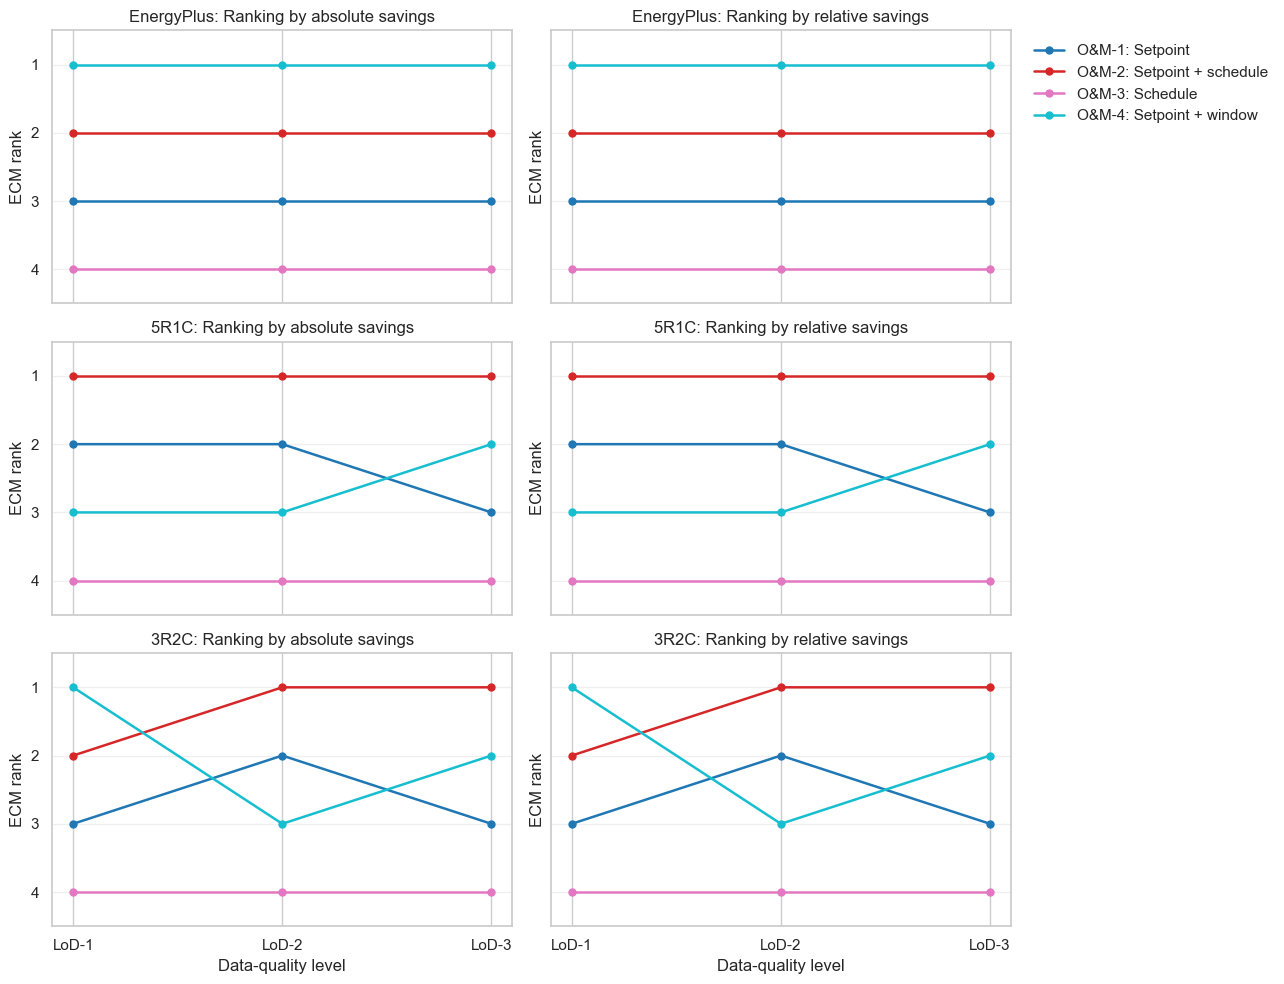

In [6]:
# ============================================================
# 3. Plot ranking variation
# ============================================================

sns.set_theme(style="whitegrid")
plt.rcParams["text.usetex"] = False

x_order = quality_order
x = np.arange(len(x_order))

cmap = plt.get_cmap("tab10")
ecm_colors = {
    ecm: mcolors.to_hex(cmap(i / max(len(common_ecm_order) - 1, 1)))
    for i, ecm in enumerate(common_ecm_order)
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(13, 10),
    sharex=True,
    sharey=True,
)

plot_specs = [
    {
        "rank_col": "Rank_abs",
        "title": "Ranking by absolute savings",
        "ylabel": "ECM rank",
    },
    {
        "rank_col": "Rank_rel",
        "title": "Ranking by relative savings",
        "ylabel": "ECM rank",
    },
]

for i, engine in enumerate(engine_order):
    for j, spec in enumerate(plot_specs):
        ax = axes[i, j]

        d_engine = rank_df[rank_df["engine"] == engine].copy()

        for ecm in common_ecm_order:
            d = (
                d_engine[d_engine["ecm_common"] == ecm]
                .set_index("data_quality")
                .reindex(x_order)
                .reset_index()
            )

            ax.plot(
                x,
                d[spec["rank_col"]],
                marker="o",
                linewidth=1.8,
                markersize=5,
                color=ecm_colors[ecm],
                label=ecm_label_map[ecm].replace("\n", " "),
            )

        ax.set_title(f"{engine}: {spec['title']}")
        ax.set_ylabel(spec["ylabel"])
        ax.set_ylim(4.5, 0.5)
        ax.set_yticks([1, 2, 3, 4])
        ax.grid(True, axis="y", alpha=0.3)

        ax.set_xticks(x)
        ax.set_xticklabels(x_order)

        if i == len(engine_order) - 1:
            ax.set_xlabel("Data-quality level")

axes[0, 1].legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

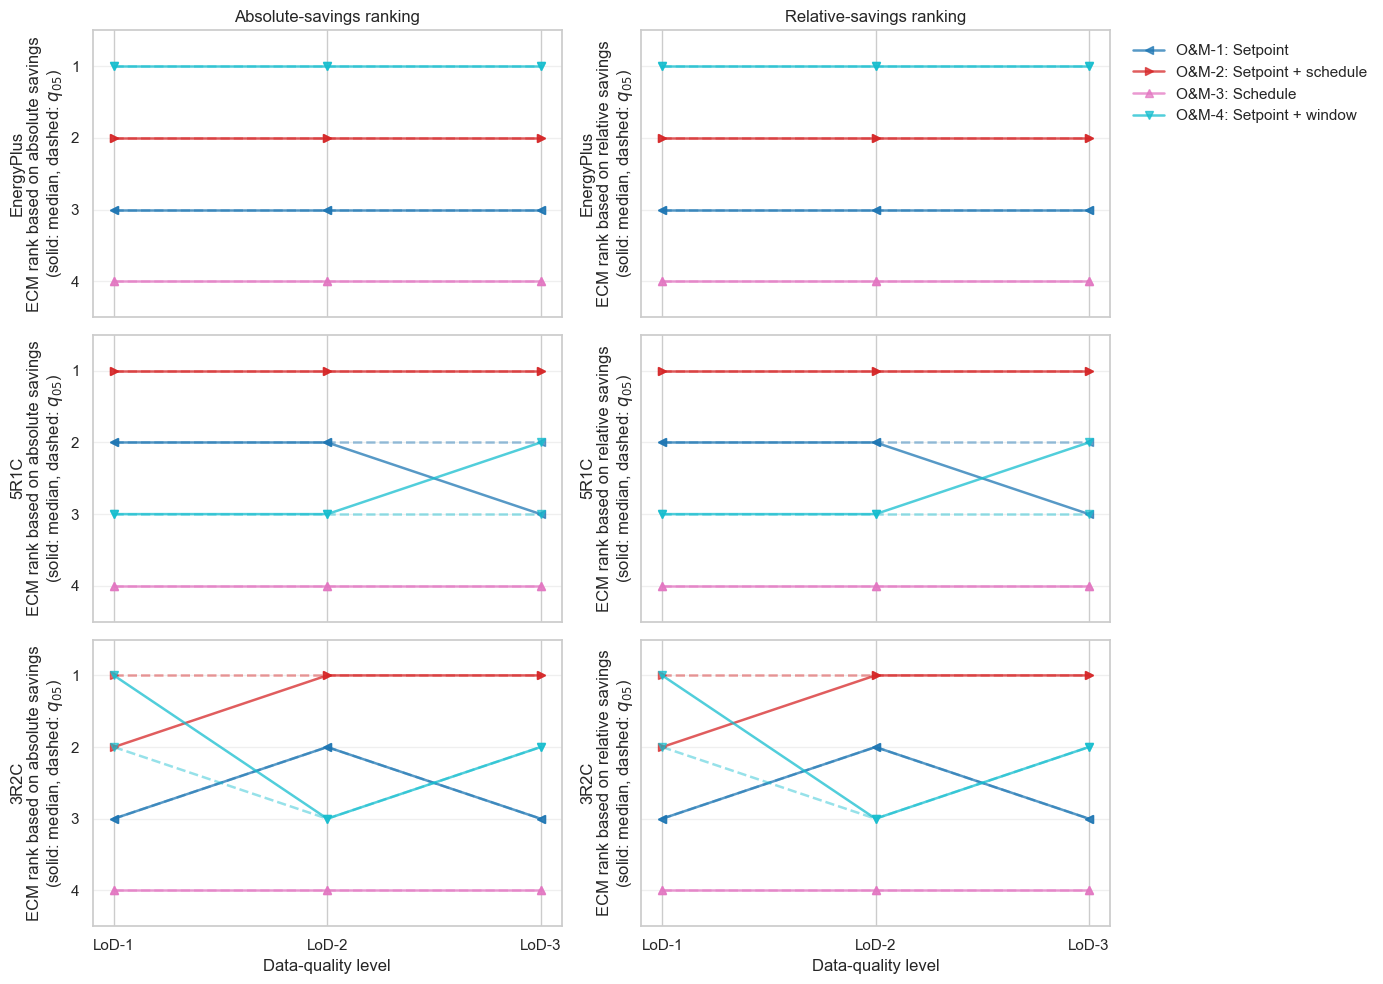

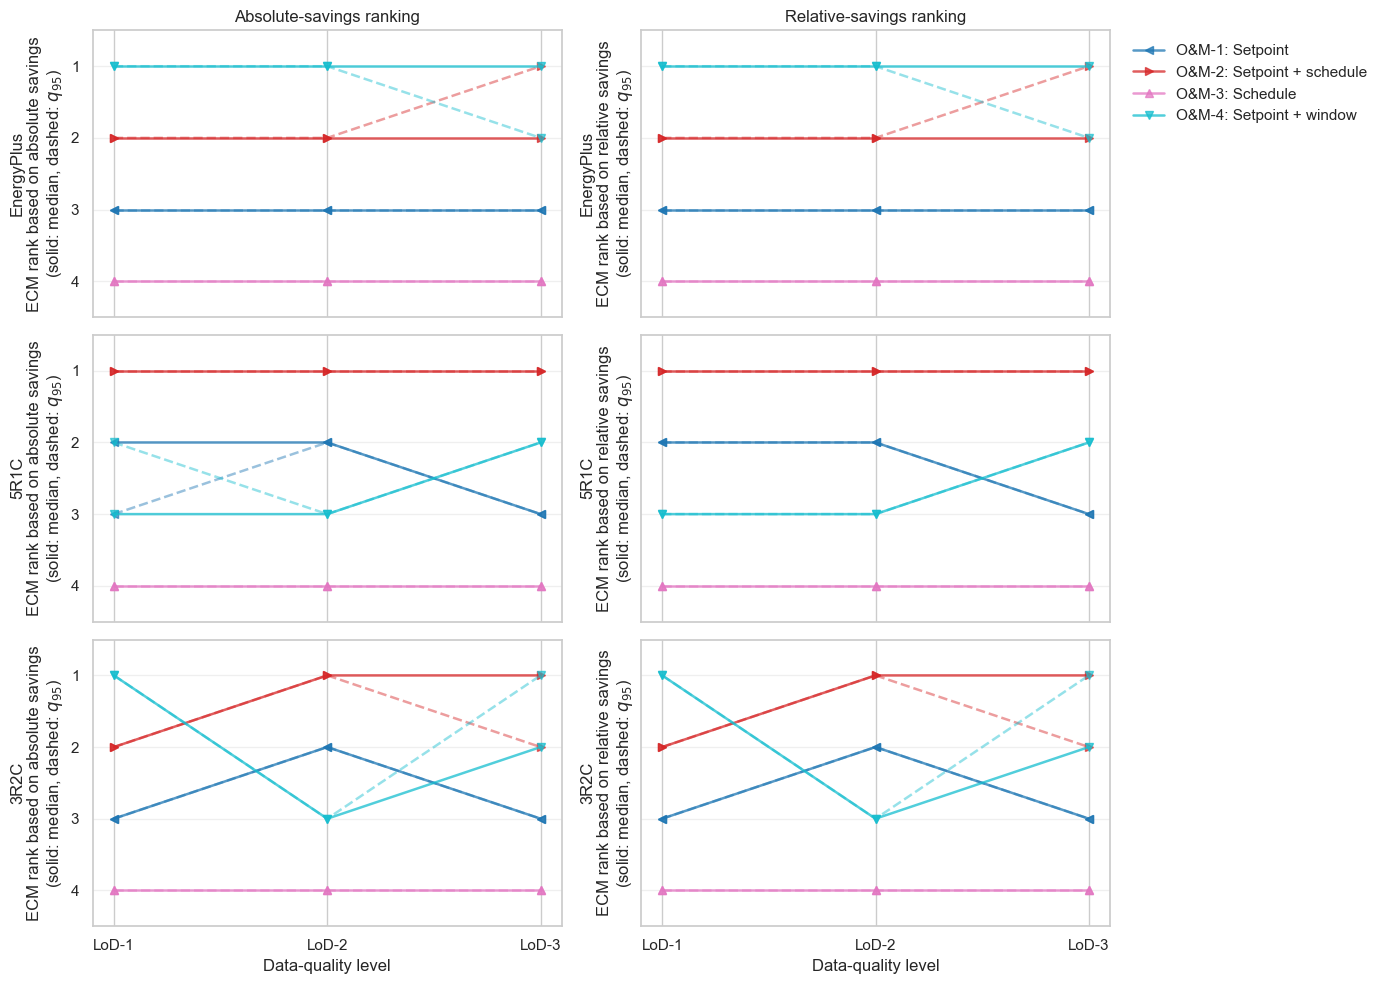

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd


# ============================================================
# Rank sensitivity plot: median rank vs q05 / q95 rank
# ============================================================

# ------------------------------------------------------------
# Expected inputs from previous blocks:
# rank_df with columns:
# engine, data_quality, ecm_common,
# Saving_abs_P5, Saving_abs_P50, Saving_abs_P95,
# Saving_rel_P5, Saving_rel_P50, Saving_rel_P95
# ------------------------------------------------------------

quality_order = ["LoD-1", "LoD-2", "LoD-3"]
engine_order = ["EnergyPlus", "5R1C", "3R2C"]
common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

ecm_label_map = {
    "O&M-1": "O&M-1: Setpoint",
    "O&M-2": "O&M-2: Setpoint + schedule",
    "O&M-3": "O&M-3: Schedule",
    "O&M-4": "O&M-4: Setpoint + window",
}

# ------------------------------------------------------------
# Alpha values
# ------------------------------------------------------------

solid_line_alpha = 0.75
dashed_line_alpha = 0.45
marker_alpha = 0.35

# ------------------------------------------------------------
# Shared x-axis setup
# ------------------------------------------------------------

x_order = quality_order
x_labels = quality_order
x = np.arange(len(x_order))

# ------------------------------------------------------------
# Symbols and colours
# ------------------------------------------------------------

marker_list = ["<", ">", "^", "v", "o", "*", "s", "P"]
cmap = plt.get_cmap("tab10")

base_colors = [
    mcolors.to_hex(cmap(i / max(len(common_ecm_order) - 1, 1)))
    for i in range(len(common_ecm_order))
]

ecm_colors = dict(zip(common_ecm_order, base_colors))

ecm_markers = {
    ecm: marker_list[i % len(marker_list)]
    for i, ecm in enumerate(common_ecm_order)
}

# ------------------------------------------------------------
# Prepare ranking columns
# ------------------------------------------------------------

rank_plot_df = rank_df.copy()

rank_plot_df["engine"] = pd.Categorical(
    rank_plot_df["engine"],
    categories=engine_order,
    ordered=True,
)

rank_plot_df["data_quality"] = pd.Categorical(
    rank_plot_df["data_quality"],
    categories=quality_order,
    ordered=True,
)

rank_plot_df["ecm_common"] = pd.Categorical(
    rank_plot_df["ecm_common"],
    categories=common_ecm_order,
    ordered=True,
)

for q_col in ["P5", "P50", "P95"]:
    rank_plot_df[f"Rank_abs_{q_col}"] = (
        rank_plot_df
        .groupby(["engine", "data_quality"], observed=True)[f"Saving_abs_{q_col}"]
        .rank(ascending=False, method="min")
    )

    rank_plot_df[f"Rank_rel_{q_col}"] = (
        rank_plot_df
        .groupby(["engine", "data_quality"], observed=True)[f"Saving_rel_{q_col}"]
        .rank(ascending=False, method="min")
    )


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def plot_rank_pair(
    ax,
    x,
    y_mid,
    y_ref,
    color,
    label,
    marker,
    linewidth=1.8,
    markersize=6,
):
    # Median rank
    ax.plot(
        x,
        y_mid,
        linestyle="-",
        marker=marker,
        linewidth=linewidth,
        markersize=markersize,
        color=color,
        alpha=solid_line_alpha,
        label=label,
    )

    # Reference rank, q05 or q95
    ax.plot(
        x,
        y_ref,
        linestyle="--",
        marker=marker,
        linewidth=linewidth,
        markersize=markersize,
        color=color,
        alpha=dashed_line_alpha,
        label=None,
    )

    # Light markers on dashed line
    ax.plot(
        x,
        y_ref,
        linestyle="None",
        marker=marker,
        markersize=markersize,
        color=color,
        alpha=marker_alpha,
        label=None,
    )


# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------

def make_rank_figure_3engines(
    ref_q="P5",
    ref_label=r"$q_{05}$",
    save_path=None,
):
    fig, axes = plt.subplots(
        nrows=len(engine_order),
        ncols=2,
        figsize=(14, 10),
        sharex=True,
        sharey=True,
    )

    plot_specs = [
        {
            "rank_prefix": "Rank_abs",
            "ylabel": f"ECM rank based on absolute savings\n(solid: median, dashed: {ref_label})",
            "title": "Absolute-savings ranking",
        },
        {
            "rank_prefix": "Rank_rel",
            "ylabel": f"ECM rank based on relative savings\n(solid: median, dashed: {ref_label})",
            "title": "Relative-savings ranking",
        },
    ]

    for i, engine in enumerate(engine_order):
        for j, spec in enumerate(plot_specs):
            ax = axes[i, j]

            d_engine = rank_plot_df[
                rank_plot_df["engine"] == engine
            ].copy()

            for ecm in common_ecm_order:
                d = (
                    d_engine[d_engine["ecm_common"] == ecm]
                    .set_index("data_quality")
                    .reindex(x_order)
                    .reset_index()
                )

                label = ecm_label_map.get(ecm, ecm)
                color = ecm_colors[ecm]
                marker = ecm_markers[ecm]

                rank_mid = d[f"{spec['rank_prefix']}_P50"].to_numpy()
                rank_ref = d[f"{spec['rank_prefix']}_{ref_q}"].to_numpy()

                plot_rank_pair(
                    ax=ax,
                    x=x,
                    y_mid=rank_mid,
                    y_ref=rank_ref,
                    color=color,
                    label=label,
                    marker=marker,
                )

            if i == 0:
                ax.set_title(spec["title"])

            ax.set_ylabel(f"{engine}\n{spec['ylabel']}")
            ax.set_ylim(4.5, 0.5)
            ax.set_yticks([1, 2, 3, 4])
            ax.grid(True, axis="y", alpha=0.3)

            ax.set_xticks(x)
            ax.set_xticklabels(x_labels, rotation=0)

            if i == len(engine_order) - 1:
                ax.set_xlabel("Data-quality level")

    axes[0, 1].legend(
        title="",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
    )

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, axes

fig_q05, axes_q05 = make_rank_figure_3engines(
    ref_q="P5",
    ref_label=r"$q_{05}$",
    save_path=Path("_json/_run/JUN11/_prediction_daily/ecm_rank_median_vs_q05.png"),
)

fig_q95, axes_q95 = make_rank_figure_3engines(
    ref_q="P95",
    ref_label=r"$q_{95}$",
    save_path=Path("_json/_run/JUN11/_prediction_daily/ecm_rank_median_vs_q95.png"),
)

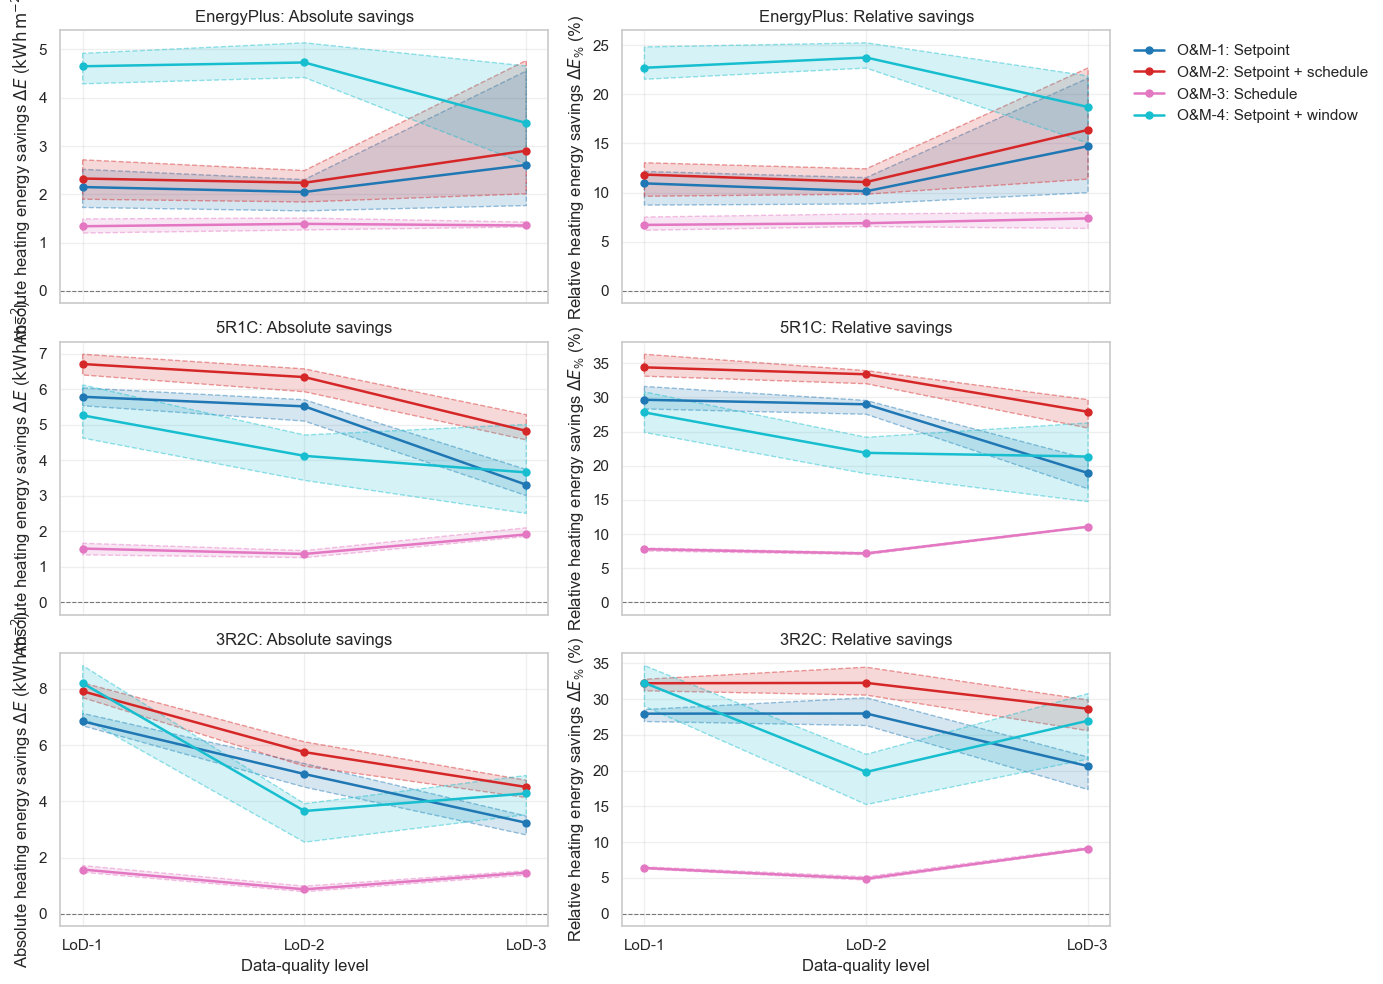

In [8]:
# ============================================================
# 4. Plot saving values with P5--P95 bands
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10),
    sharex=True,
)

value_specs = [
    {
        "p5": "Saving_abs_P5",
        "p50": "Saving_abs_P50",
        "p95": "Saving_abs_P95",
        "ylabel": r"Absolute heating energy savings $\Delta E$ ($\mathrm{kWh\,m^{-2}}$)",
        "title": "Absolute savings",
    },
    {
        "p5": "Saving_rel_P5",
        "p50": "Saving_rel_P50",
        "p95": "Saving_rel_P95",
        "ylabel": r"Relative heating energy savings $\Delta E_{\%}$ (%)",
        "title": "Relative savings",
    },
]

BAND_ALPHA = 0.18
EDGE_ALPHA = 0.45

for i, engine in enumerate(engine_order):
    for j, spec in enumerate(value_specs):
        ax = axes[i, j]

        d_engine = rank_df[rank_df["engine"] == engine].copy()

        for ecm in common_ecm_order:
            color = ecm_colors[ecm]

            d = (
                d_engine[d_engine["ecm_common"] == ecm]
                .set_index("data_quality")
                .reindex(x_order)
                .reset_index()
            )

            ax.plot(
                x,
                d[spec["p50"]],
                marker="o",
                linewidth=1.8,
                markersize=5,
                label=ecm_label_map[ecm].replace("\n", " "),
                color=color,
            )

            ax.fill_between(
                x,
                d[spec["p5"]],
                d[spec["p95"]],
                facecolor=mcolors.to_rgba(color, BAND_ALPHA),
                edgecolor=mcolors.to_rgba(color, EDGE_ALPHA),
                linewidth=1.0,
                linestyle="--",
            )

        ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.set_title(f"{engine}: {spec['title']}")
        ax.set_ylabel(spec["ylabel"])
        ax.grid(True, alpha=0.3)

        ax.set_xticks(x)
        ax.set_xticklabels(x_order)

        if i == len(engine_order) - 1:
            ax.set_xlabel("Data-quality level")

axes[0, 1].legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()